In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# TÜİK verisi
tuik = pd.read_csv('data/genc_issizlik_egitim.csv')
tuik.head()

,Yıl,Eğitim Durumu,İşsizlik Oranı (%)
0,2020,İlkokul altı,25.1
1,2020,Ortaokul,24.3
2,2020,Lise,19.8
3,2020,Önlisans,16.5
4,2020,Lisans,15.2


In [5]:
# Akademik makale verisi
akademik = pd.read_csv('data/akademik_issizlik_verisi.csv')
akademik.head()

,Yıl,Eğitim Durumu,İşsizlik Oranı (%)
0,2005,İlkokul altı,15.2
1,2006,İlkokul altı,15.8
2,2007,İlkokul altı,16.1
3,2008,İlkokul altı,15.9
4,2009,İlkokul altı,15.6


In [7]:
# Her veri setinin genel bilgisi
print("TÜİK Verisi:")
print(tuik.info())
print("\nAkademik Verisi:")
print(akademik.info())

TÜİK Verisi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Yıl                 24 non-null     int64  
 1   Eğitim Durumu       24 non-null     object 
 2   İşsizlik Oranı (%)  24 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 708.0+ bytes
None

Akademik Verisi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Yıl                 45 non-null     int64  
 1   Eğitim Durumu       45 non-null     object 
 2   İşsizlik Oranı (%)  45 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.2+ KB
None


In [9]:
# Eksik veri sayısı
print("TÜİK Eksik Veriler:\n", tuik.isnull().sum())
print("\nAkademik Eksik Veriler:\n", akademik.isnull().sum())

TÜİK Eksik Veriler:
 Yıl                   0
Eğitim Durumu         0
İşsizlik Oranı (%)    0
dtype: int64

Akademik Eksik Veriler:
 Yıl                   0
Eğitim Durumu         0
İşsizlik Oranı (%)    0
dtype: int64


In [11]:
print("TÜİK Sütunları:", tuik.columns)
print("Akademik Sütunlar:", akademik.columns)

TÜİK Sütunları: Index(['Yıl', 'Eğitim Durumu', 'İşsizlik Oranı (%)'], dtype='object')
Akademik Sütunlar: Index(['Yıl', 'Eğitim Durumu', 'İşsizlik Oranı (%)'], dtype='object')


In [13]:
# TÜİK ve Akademik veri: sütun isimlerini Türkçeleştiriyoruz
tuik = tuik.rename(columns={
    'Yıl': 'Yıl',
    'Eğitim Durumu': 'Eğitim_Durumu',
    'İşsizlik Oranı (%)': 'İşsizlik_Orani'
})

akademik = akademik.rename(columns={
    'Yıl': 'Yıl',
    'Eğitim Durumu': 'Eğitim_Durumu',
    'İşsizlik Oranı (%)': 'İşsizlik_Orani'
})

# Kaggle verisinde Türkçeleştirme
kaggle = kaggle.rename(columns={
    'Year': 'Yıl',
    'Indicator_Name': 'Gosterge_Adi',
    'Value': 'İşsizlik_Orani'
})

NameError: name 'kaggle' is not defined

In [ ]:
# TÜİK Verisi: Eğitim durumuna göre işsizlik oranı

plt.figure(figsize=(10, 6))
sns.lineplot(data=tuik, x='Yıl', y='İşsizlik_Orani', hue='Eğitim_Durumu', marker='s')

plt.title('TÜİK Verisi - Eğitim Durumuna Göre İşsizlik Oranı')
plt.xlabel('Yıl')
plt.ylabel('İşsizlik Oranı (%)')
plt.grid(True)
plt.legend(title='Eğitim Durumu')
plt.tight_layout()
plt.show()

In [ ]:
# Akademik Makale Verisi: Eğitim durumuna göre

plt.figure(figsize=(10, 6))
sns.lineplot(data=akademik, x='Yıl', y='İşsizlik_Orani', hue='Eğitim_Durumu', marker='p')

plt.title('Akademik Veri - Eğitim Durumuna Göre İşsizlik Oranı')
plt.xlabel('Yıl')
plt.ylabel('İşsizlik Oranı (%)')
plt.grid(True)
plt.legend(title='Eğitim Durumu')
plt.tight_layout()
plt.show()


In [17]:
# TÜİK ortalama işsizlik oranları DataFrame olarak
tuik_ortalama = tuik.groupby('Eğitim_Durumu')['İşsizlik_Orani'].mean().reset_index()
tuik_ortalama

,Eğitim_Durumu,İşsizlik_Orani
0,Lisans,13.975
1,Lise,18.950
2,Ortaokul,23.025
3,Yüksek Lisans ve üzeri,12.075
4,Önlisans,15.950
5,İlkokul altı,24.900


In [19]:
# Akademik ortalama işsizlik oranları DataFrame olarak
akademik_ortalama = akademik.groupby('Eğitim_Durumu')['İşsizlik_Orani'].mean().reset_index()
akademik_ortalama

,Eğitim_Durumu,İşsizlik_Orani
0,Lisans,17.280000
1,Lise,17.140000
2,İlkokul altı,14.566667


In [21]:
# Ortak eğitim durumlarını bul
ortak_egitim = set(tuik_ortalama['Eğitim_Durumu']).intersection(set(akademik_ortalama['Eğitim_Durumu']))

# Ortak eğitim durumlarına göre filtrele
tuik_filtreli = tuik_ortalama[tuik_ortalama['Eğitim_Durumu'].isin(ortak_egitim)].sort_values('Eğitim_Durumu')
akademik_filtreli = akademik_ortalama[akademik_ortalama['Eğitim_Durumu'].isin(ortak_egitim)].sort_values('Eğitim_Durumu')

# Aynı eğitim durumları sırasına göre indexleri sıfırla
tuik_filtreli = tuik_filtreli.reset_index(drop=True)
akademik_filtreli = akademik_filtreli.reset_index(drop=True)


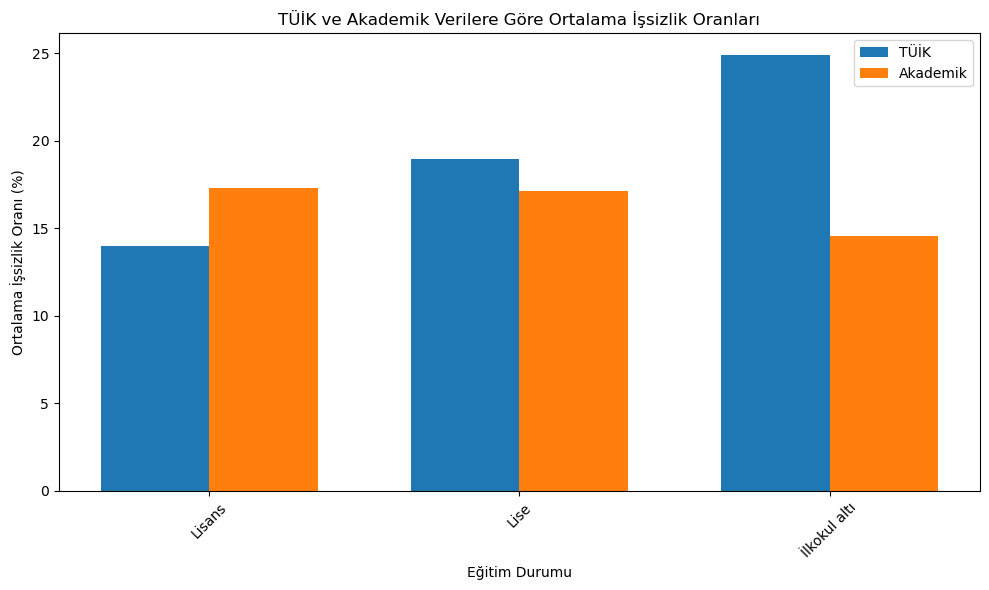

In [23]:
# Karşılaştırmalı Görselleştirme

egitim_durumlari = tuik_filtreli['Eğitim_Durumu']
x = np.arange(len(egitim_durumlari))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
bar1 = ax.bar(x - width/2, tuik_filtreli['İşsizlik_Orani'], width, label='TÜİK')
bar2 = ax.bar(x + width/2, akademik_filtreli['İşsizlik_Orani'], width, label='Akademik')

ax.set_xlabel('Eğitim Durumu')
ax.set_ylabel('Ortalama İşsizlik Oranı (%)')
ax.set_title('TÜİK ve Akademik Verilere Göre Ortalama İşsizlik Oranları')
ax.set_xticks(x)
ax.set_xticklabels(egitim_durumlari, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()
